In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Tourism_Cluster_DFO_2023.xlsx to Tourism_Cluster_DFO_2023.xlsx


In [3]:
df = pd.read_excel(
    "Tourism_Cluster_DFO_2023.xlsx",
    sheet_name="Tourism_2023"
)

df

,Region_ID,Region_EN,Collective_Accommodation,Collective_Tourists,Tour_Firms,Tour_Packages,Domestic_Tourists_By_Firms,Outbound_Tourists_By_Firms,Theater_Visitors_per_1000,Museum_Visits_per_1000,Retail_Turnover_2023,Paid_Services_2023
0,1,Republic of Buryatia,508,564,46,6.0,7.6,5.3,263,401,269578,61265
1,2,Republic of Sakha (Yakutia),211,235,74,15.0,21.2,14.1,242,500,353740,109466
2,3,Zabaykalsky Krai,215,382,27,9.4,1.3,17.9,276,324,244239,72320
3,4,Kamchatka Krai,111,228,114,13.1,16.3,5.3,271,548,101193,33405
4,5,Primorsky Krai,628,1231,118,49.9,15.1,54.0,318,235,646506,210225
5,6,Khabarovsk Krai,227,699,113,27.4,26.8,29.4,246,302,466944,161163
6,7,Amur Oblast,194,354,59,16.6,4.8,23.5,172,546,267573,60872
7,8,Magadan Oblast,27,125,7,0.9,0.3,1.6,350,196,48751,16213
8,9,Sakhalin Oblast,117,245,38,9.4,11.9,6.1,246,1077,207434,57831
9,10,Jewish Autonomous Oblast,31,45,5,0.0,0.0,1.4,138,180,37876,11651


In [4]:
X = df.iloc[:, 2:]

X.head()

,Collective_Accommodation,Collective_Tourists,Tour_Firms,Tour_Packages,Domestic_Tourists_By_Firms,Outbound_Tourists_By_Firms,Theater_Visitors_per_1000,Museum_Visits_per_1000,Retail_Turnover_2023,Paid_Services_2023
0,508,564,46,6.0,7.6,5.3,263,401,269578,61265
1,211,235,74,15.0,21.2,14.1,242,500,353740,109466
2,215,382,27,9.4,1.3,17.9,276,324,244239,72320
3,111,228,114,13.1,16.3,5.3,271,548,101193,33405
4,628,1231,118,49.9,15.1,54.0,318,235,646506,210225


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 1.6057612 ,  0.56568437, -0.20970928, -0.53209368, -0.2208638 ,
        -0.58602706,  0.36797842, -0.30192295,  0.15020283, -0.18506011],
       [ 0.01412836, -0.41525082,  0.44937704,  0.112671  ,  1.30177325,
        -0.0204496 ,  0.13885978,  0.00826016,  0.60305507,  0.59819652],
       [ 0.03556449,  0.02303937, -0.65694643, -0.28851591, -0.92620301,
         0.22377703,  0.50981377, -0.54317647,  0.01386074, -0.00541857],
       [-0.52177495, -0.43612178,  1.39092892, -0.02344599,  0.75317608,
        -0.58602706,  0.45526172,  0.15865196, -0.75582988, -0.63777955],
       [ 2.24884517,  2.55438883,  1.48508411,  2.61292514,  0.61882575,
         2.54393005,  0.96805105, -0.82202795,  2.17834722,  2.23551016],
       [ 0.09987289,  0.96819577,  1.36739012,  1.00101345,  1.92874144,
         0.96288395,  0.18250143, -0.61210605,  1.2121742 ,  1.43826245],
       [-0.0769752 , -0.06044447,  0.09629508,  0.22729583, -0.53434789,
         0.58368997, -0.62486902,  0.15238564

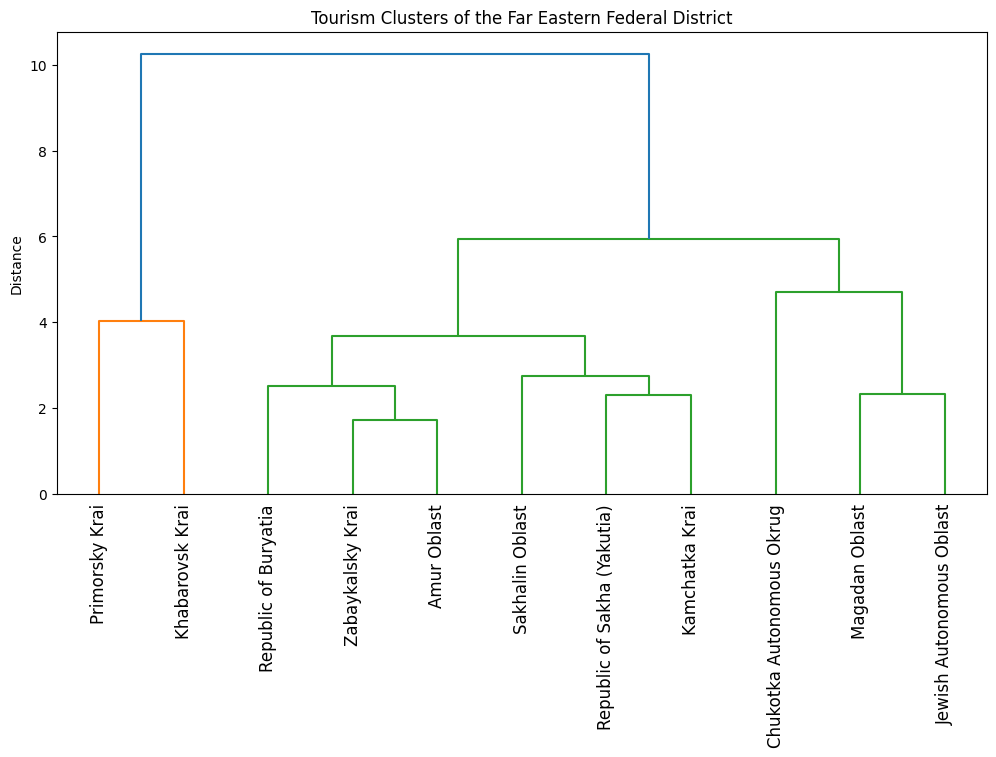

In [6]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    labels=df["Region_EN"].values,
    leaf_rotation=90
)

plt.title("Tourism Clusters of the Far Eastern Federal District")
plt.ylabel("Distance")

plt.show()

In [7]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df[["Region_EN","Cluster"]]

,Region_EN,Cluster
0,Republic of Buryatia,2
1,Republic of Sakha (Yakutia),2
2,Zabaykalsky Krai,2
3,Kamchatka Krai,2
4,Primorsky Krai,1
5,Khabarovsk Krai,1
6,Amur Oblast,2
7,Magadan Oblast,0
8,Sakhalin Oblast,2
9,Jewish Autonomous Oblast,0


In [8]:
df.sort_values("Cluster")[["Region_EN","Cluster"]]

,Region_EN,Cluster
7,Magadan Oblast,0
9,Jewish Autonomous Oblast,0
10,Chukotka Autonomous Okrug,0
4,Primorsky Krai,1
5,Khabarovsk Krai,1
2,Zabaykalsky Krai,2
3,Kamchatka Krai,2
0,Republic of Buryatia,2
6,Amur Oblast,2
1,Republic of Sakha (Yakutia),2


In [9]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,Region_ID,Collective_Accommodation,Collective_Tourists,Tour_Firms,Tour_Packages,Domestic_Tourists_By_Firms,Outbound_Tourists_By_Firms,Theater_Visitors_per_1000,Museum_Visits_per_1000,Retail_Turnover_2023,Paid_Services_2023
Cluster,,,,,,,,,,,
0,9.666667,27.0,59.666667,5.000000,0.300000,0.100000,1.000000,162.666667,512.666667,33695.333333,10880.333333
1,5.500000,427.5,965.000000,115.500000,38.650000,20.950000,41.700000,282.000000,268.500000,556725.000000,185694.000000
2,4.333333,226.0,334.666667,59.666667,11.583333,10.516667,12.033333,245.000000,566.000000,240626.166667,65859.833333


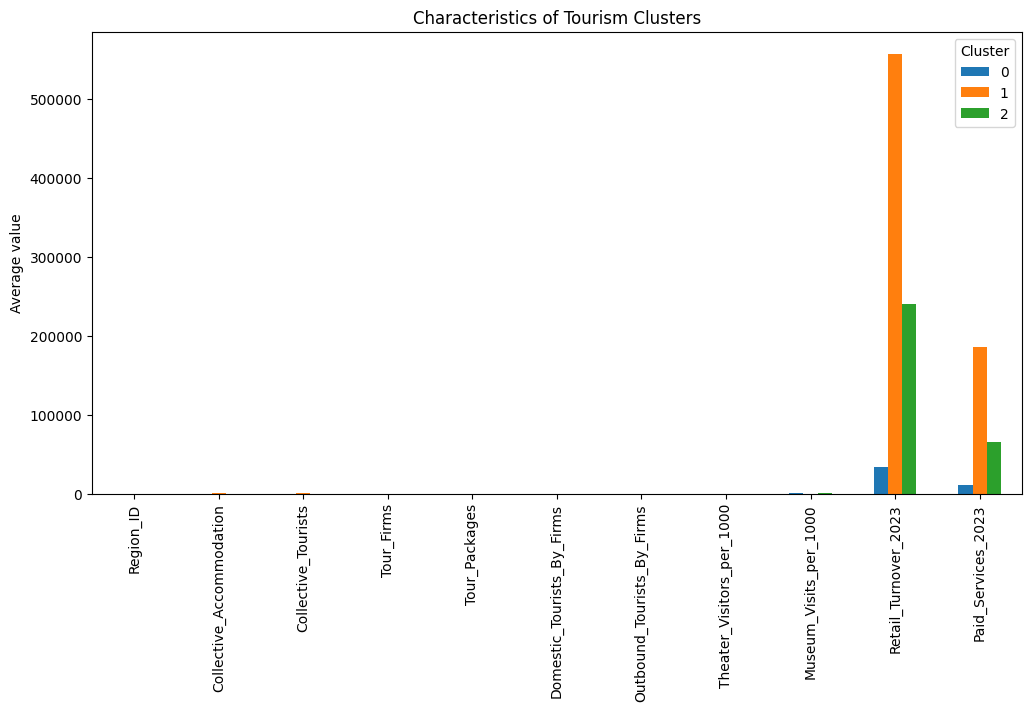

In [10]:
cluster_summary.T.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Characteristics of Tourism Clusters")
plt.ylabel("Average value")
plt.show()

In [11]:
cluster_summary

,Region_ID,Collective_Accommodation,Collective_Tourists,Tour_Firms,Tour_Packages,Domestic_Tourists_By_Firms,Outbound_Tourists_By_Firms,Theater_Visitors_per_1000,Museum_Visits_per_1000,Retail_Turnover_2023,Paid_Services_2023
Cluster,,,,,,,,,,,
0,9.666667,27.0,59.666667,5.000000,0.300000,0.100000,1.000000,162.666667,512.666667,33695.333333,10880.333333
1,5.500000,427.5,965.000000,115.500000,38.650000,20.950000,41.700000,282.000000,268.500000,556725.000000,185694.000000
2,4.333333,226.0,334.666667,59.666667,11.583333,10.516667,12.033333,245.000000,566.000000,240626.166667,65859.833333


In [12]:
pd.set_option('display.max_columns', None)

cluster_summary.round(2)

,Region_ID,Collective_Accommodation,Collective_Tourists,Tour_Firms,Tour_Packages,Domestic_Tourists_By_Firms,Outbound_Tourists_By_Firms,Theater_Visitors_per_1000,Museum_Visits_per_1000,Retail_Turnover_2023,Paid_Services_2023
Cluster,,,,,,,,,,,
0,9.67,27.0,59.67,5.00,0.30,0.10,1.00,162.67,512.67,33695.33,10880.33
1,5.50,427.5,965.00,115.50,38.65,20.95,41.70,282.00,268.50,556725.00,185694.00
2,4.33,226.0,334.67,59.67,11.58,10.52,12.03,245.00,566.00,240626.17,65859.83
